In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
import pyBigWig as pbw
import seaborn as sns
import gzip
from scipy.stats import linregress
from scipy.stats import mannwhitneyu
import matplotlib as mpl
import pandas as pd
import pyBigWig
from matplotlib.lines import Line2D
from collections import defaultdict


mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
colo_alpha_sat_file= 'colo/DSA_COLO829BL_v3.0.0_1_2.trimmed_CHM13-centromere.stats.DSA.start2end.ALR_Alpha.100kb.10kb_merge.bed'

colo_bl_file = 'colo/bl/COLO829BL_DSA.combined.zhtr_minus1_25.bed'

colo_ta_file = 'colo/t/COLO829TA_DSA.combined.zhtr_minus1_25.bed'
colo_tb_file = 'colo/t/COLO829TB_DSA.combined.zhtr_minus1_25.bed'

In [4]:
colo_bl_dimelo = 'dimelo/colo829b.dimelo.m6a.bw'
colo_tb_dimelo = 'dimelo/colo829t.dimelo.m6a.bw'

COLO829BL fold difference: 4.844894655149139, pval (mwu): 1.5822164582832159e-16
COLO829TB fold difference: 5.136762038097969, pval (mwu): 2.6291160832906466e-13


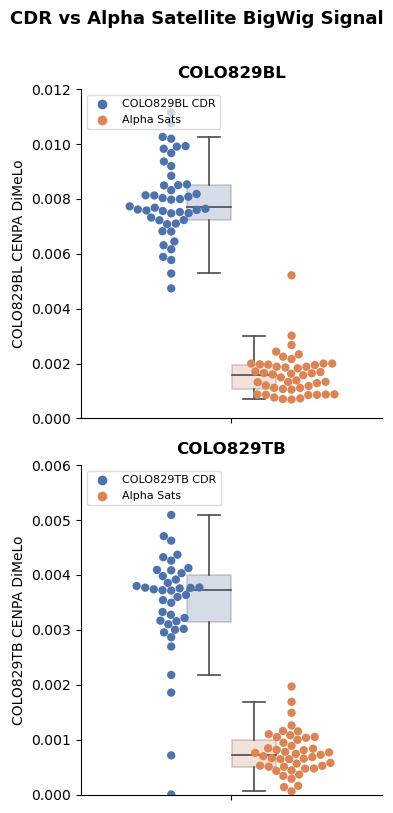

In [23]:


def get_chrom_mean_from_bigwig(bed_file: str, bw_file: str) -> dict[str, float]:

    chrom_values: dict[str, list[float]] = defaultdict(list)

    bw = pbw.open(bw_file)
    try:
        with open(bed_file) as fh:
            for line in fh:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                parts = line.split("\t")
                chrom, start, end = parts[0], int(parts[1]), int(parts[2])

                vals = bw.stats(chrom, start, end, type="mean", nBins=1)
                if vals and vals[0] is not None:
                    chrom_values[chrom].append(vals[0])
    finally:
        bw.close()

    return {chrom: float(np.mean(v)) for chrom, v in chrom_values.items() if v}


def plot_bigwig_swarm(
    bed1_file: str,
    bed2_file: str,
    bw_file: str,
    group1_label: str = "Group 1",
    group2_label: str = "Group 2",
    title: str = "Mean BigWig Signal per Chromosome",
    ylabel: str = "Mean Signal",
    palette: list[str] | None = None,
    figsize: tuple[int, int] = (7, 5),
    ax: plt.Axes | None = None,
    save_path: str | None = None,
) -> pd.DataFrame:

    palette = palette or ["#4C72B0", "#DD8452"]

    means1 = get_chrom_mean_from_bigwig(bed1_file, bw_file)
    means2 = get_chrom_mean_from_bigwig(bed2_file, bw_file)

    rows = (
        [{"chrom": c, "mean_signal": v, "group": group1_label} for c, v in means1.items()]
        + [{"chrom": c, "mean_signal": v, "group": group2_label} for c, v in means2.items()]
    )
    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("No valid data found — check BED coordinates vs BigWig chromosomes.")

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize)

    sns.swarmplot(
        data=df,
        x="group",
        y="mean_signal",
        hue="group",
        palette=palette,
        size=7,
        ax=ax,
        legend=False,
    )

    # Overlay a thin box to show spread without hiding points
    sns.boxplot(
        data=df,
        x="group",
        y="mean_signal",
        palette=palette,
        width=0.35,
        linewidth=1.2,
        fliersize=0,       # outlier markers hidden — swarm already shows them
        boxprops=dict(alpha=0.25),
        ax=ax,
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis="x", labelsize=11)
    sns.despine(ax=ax)

    for xtick, label in enumerate(df["group"].unique()):
        n = df[df["group"] == label].shape[0]
        ax.text(xtick, ax.get_ylim()[0], f"n={n}", ha="center", va="top",
                fontsize=9, color="gray")

    if own_fig:
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()

    return df

def plot_bigwig_swarm_multi(
    configs: list[dict],
    figsize: tuple[int, int] | None = None,
    save_path: str | None = None,
) -> list[pd.DataFrame]:

    n = len(configs)
    figsize = figsize or (4, 4 * n)
    fig, axes = plt.subplots(n, 1, figsize=figsize)   # ← single column
    if n == 1:
        axes = [axes]

    all_dfs = []
    y_lims = [(0, 0.012), (0, 0.006)]

    for ax, cfg, yl in zip(axes, configs, y_lims):
        palette = cfg.get("palette", ["#4C72B0", "#DD8452"])

        means1 = get_chrom_mean_from_bigwig(cfg["bed1_file"], cfg["bw_file"])
        means2 = get_chrom_mean_from_bigwig(cfg["bed2_file"], cfg["bw_file"])

        rows = (
            [{"chrom": c, "mean_signal": v, "group": cfg["group1_label"]} for c, v in means1.items()]
            + [{"chrom": c, "mean_signal": v, "group": cfg["group2_label"]} for c, v in means2.items()]
        )
        df = pd.DataFrame(rows)
        df["_x"] = ""          # ← single dummy x — both groups share one column
        all_dfs.append(df)

        g1 = df[df["group"] == cfg["group1_label"]]["mean_signal"].values
        g2 = df[df["group"] == cfg["group2_label"]]["mean_signal"].values

        med_g1   = np.median(g1)
        med_g2   = np.median(g2)
        fold_diff = med_g1/med_g2
        stat, pval = mannwhitneyu(g1, g2, alternative="two-sided")
        print(cfg['title'],f'fold difference: {fold_diff}, pval (mwu): {pval}')

        sns.swarmplot(
            data=df, x="_x", y="mean_signal",
            hue="group", palette=palette,
            dodge=True,           # jitter each hue group to its own swarm lane
            size=6, ax=ax,
        )
        sns.boxplot(
            data=df, x="_x", y="mean_signal",
            hue="group", palette=palette,
            dodge=True,
            width=0.3, linewidth=1.2,
            fliersize=0, boxprops=dict(alpha=0.25), ax=ax,
        )
        ax.get_legend().remove()   # ← drop the duplicate boxplot legend

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title="", loc="upper left",
                  fontsize=8, framealpha=0.7)

        ax.set_title(cfg.get("title", ""), fontsize=12, fontweight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_ylabel(cfg.get("ylabel", "Mean Signal"), fontsize=10)
        ax.tick_params(axis="x", labelsize=9)
        ax.set_ylim(yl)
        sns.despine(ax=ax)
    fig.suptitle("CDR vs Alpha Satellite BigWig Signal", fontsize=13,
                 fontweight="bold", y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return all_dfs


configs = [
    dict(
        bed1_file    = colo_bl_file,
        bed2_file    = colo_alpha_sat_file,
        bw_file      = colo_bl_dimelo,
        group1_label = "COLO829BL CDR",
        group2_label = "Alpha Sats",
        ylabel       = "COLO829BL CENPA DiMeLo",
        title        = "COLO829BL",
    ),
    dict(
        bed1_file    = colo_tb_file,
        bed2_file    = colo_alpha_sat_file,
        bw_file      = colo_tb_dimelo,
        group1_label = "COLO829TB CDR",
        group2_label = "Alpha Sats",
        ylabel       = "COLO829TB CENPA DiMeLo",
        title        = "COLO829TB",
    ),
]

dfs = plot_bigwig_swarm_multi(configs, save_path="colo_dimelo_swarm_comparison.pdf")

In [5]:
# Count haplotypes (contigs) that contain at least one CDR overlapping an
# alpha-satellite region. Reported for COLO829BL against the COLO829 DSA alpha-sat set.

def count_haplotypes_with_cdr(cdr_bed, alpha_sat_bed, contained_only=False):
    """Return the set of contigs on which ≥1 CDR overlaps an alpha-sat region.

    Overlap rule:
      - contained_only=False (default): any half-open overlap counts
      - contained_only=True           : only CDRs fully contained in an alpha-sat region count
    """
    def _open(p):
        return gzip.open(p, "rt") if p.endswith(".gz") else open(p, "rt")

    def _parse_bed(p):
        d = {}
        with _open(p) as f:
            for line in f:
                if not line.strip() or line.startswith(("#", "track", "browser")):
                    continue
                parts = line.split()
                if len(parts) < 3:
                    continue
                c, s, e = parts[0], int(parts[1]), int(parts[2])
                if e > s:
                    d.setdefault(c, []).append((s, e))
        return d

    cdrs  = _parse_bed(cdr_bed)
    alpha = _parse_bed(alpha_sat_bed)

    haps_with_cdr = set()
    for chrom, regions in alpha.items():
        if chrom not in cdrs:
            continue
        for rs, re in regions:
            hit = False
            for s, e in cdrs[chrom]:
                if contained_only:
                    if s >= rs and e <= re:
                        hit = True
                        break
                else:
                    if e > rs and s < re:
                        hit = True
                        break
            if hit:
                haps_with_cdr.add(chrom)
                break
    return haps_with_cdr


# COLO829BL — number of haplotypes containing a CDR within an alpha-satellite
_bl_haps = count_haplotypes_with_cdr(colo_bl_file, colo_alpha_sat_file, contained_only=False)
print(f'COLO829BL: {len(_bl_haps)} haplotypes contain ≥1 CDR within an alpha-satellite region')

# (Same metric for the tumor passages, for context)
_ta_haps = count_haplotypes_with_cdr(colo_ta_file, colo_alpha_sat_file, contained_only=False)
_tb_haps = count_haplotypes_with_cdr(colo_tb_file, colo_alpha_sat_file, contained_only=False)
print(f'COLO829TA: {len(_ta_haps)} haplotypes contain ≥1 CDR within an alpha-satellite region')
print(f'COLO829TB: {len(_tb_haps)} haplotypes contain ≥1 CDR within an alpha-satellite region')

FileNotFoundError: [Errno 2] No such file or directory: 'colo/bl/COLO829BL_DSA.combined.zhtr_minus1_25.bed'

In [10]:


def center_of_mass_per_chrom(coords_bed, regions_bed, contained_only=False):

    def _open(path):
        return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")

    def _parse_bed(path):
        d = {}
        with _open(path) as f:
            for line in f:
                if not line.strip() or line.startswith(("#","track","browser")):
                    continue
                p = line.split()
                if len(p) < 3:
                    continue
                c, s, e = p[0], int(p[1]), int(p[2])
                if e > s:
                    d.setdefault(c, []).append((s, e))
        return d

    regions = _parse_bed(regions_bed)
    coords  = _parse_bed(coords_bed)

    largest = {}
    for c, lst in regions.items():
        best = None
        best_len = -1
        for s, e in lst:
            L = e - s
            if L > best_len:
                best = (s, e); best_len = L
        if best:
            largest[c] = best

    out = {}
    for c, (rs, re) in largest.items():
        if c not in coords:
            out[c] = None
            continue

        num = 0.0  
        den = 0.0  
        
        for s, e in coords[c]:
            if contained_only:
                if s < rs or e > re:
                    continue
                a, b = s, e
            else:
                a = max(s, rs)
                b = min(e, re)

                if b <= a:
                    continue
    
            L = b - a
            mid = (a + b) / 2.0
            num += mid * L
            den += L

        out[c] = (num / den) if den > 0 else None

    return out

In [11]:
def cdr_size(coords_bed, regions_bed, contained_only=False):

    def _open(path):
        return gzip.open(path, "rt") if path.endswith(".gz") else open(path, "rt")

    def _parse_bed(path):
        d = {}
        with _open(path) as f:
            for line in f:
                if not line.strip() or line.startswith(("#","track","browser")):
                    continue
                p = line.split()
                if len(p) < 3:
                    continue
                c, s, e = p[0], int(p[1]), int(p[2])
                if e > s:
                    d.setdefault(c, []).append((s, e))
        return d

    regions = _parse_bed(regions_bed)
    coords  = _parse_bed(coords_bed)

    largest = {}
    for c, lst in regions.items():
        best = None
        best_len = -1
        for s, e in lst:
            L = e - s
            if L > best_len:
                best = (s, e); best_len = L
        if best:
            largest[c] = best

    out = {}
    for c, (rs, re) in largest.items():
        # no coords on this chrom
        if c not in coords:
            out[c] = None
            continue

        num = 0.0  # sum of all lengths

        for s, e in coords[c]:
            if contained_only:
                if s < rs or e > re:
                    continue
                a, b = s, e
            else:
                a = max(s, rs)
                b = min(e, re)
                if b <= a:
                    continue

            L = b - a
            num += L

        out[c] = num

    return out

In [13]:
def count_entries_per_region(bedA, bedB, regions_bed, contained_only=False):

    def _open(p): return gzip.open(p, "rt") if p.endswith(".gz") else open(p, "rt")

    def _parse_bed(p):
        by_chrom = {}
        with _open(p) as f:
            for line in f:
                if not line.strip() or line.startswith(("track", "browser", "#")):
                    continue
                parts = line.split()
                if len(parts) < 3:
                    continue
                c, s, e = parts[0], int(parts[1]), int(parts[2])
                if e > s:
                    by_chrom.setdefault(c, []).append((s, e))
        for c in by_chrom:
            by_chrom[c].sort()
        return by_chrom

    def _regions_by_chrom(p):
        by_chrom = {}
        order = []  
        with _open(p) as f:
            for line in f:
                if not line.strip() or line.startswith(("#", "track", "browser")):
                    continue
                parts = line.split()
                if len(parts) < 3: 
                    continue
                c, rs, re = parts[0], int(parts[1]), int(parts[2])
                if re > rs:
                    by_chrom.setdefault(c, []).append((rs, re))
                    order.append((c, rs, re))
        for c in by_chrom:
            by_chrom[c].sort()
        return by_chrom

    def _count_overlaps(intervals, regions, contained_only):

        counts = []
        i = 0  # left index into intervals
        n = len(intervals)
        for rs, re in regions:
            while i < n and intervals[i][1] <= rs:
                i += 1
            j = i
            cnt = 0
            while j < n and intervals[j][0] < re:
                s, e = intervals[j]
                if contained_only:
                    if s >= rs and e <= re:
                        cnt += 1
                else:
                    if e > rs and s < re:  # any overlap
                        cnt += 1
                j += 1
            counts.append(cnt)
        return counts

    A = _parse_bed(bedA)
    B = _parse_bed(bedB)
    R = _regions_by_chrom(regions_bed)

    per_chrom = {}
    chroms = set(R.keys()) | set(A.keys()) | set(B.keys())
    for chrom in sorted(chroms):
        regions = R.get(chrom, [])
        if not regions:
            continue
        a_ints = A.get(chrom, [])
        b_ints = B.get(chrom, [])

        a_counts = _count_overlaps(a_ints, regions, contained_only)
        b_counts = _count_overlaps(b_ints, regions, contained_only)

        per_chrom[chrom] = [
            {"region": (rs, re), "count_A": ca, "count_B": cb}
            for (rs, re), ca, cb in zip(regions, a_counts, b_counts)
        ]

    return per_chrom

def plot_paired_counts(ax, res_dict, name_A, name_B, color):
    keys = []
    
    for r in res_dict.values():
        y1, y2 = 0, 0
        for sr in r:
            y1 += sr['count_A']
            y2 += sr['count_B']
            
        if y2 == 0: 
            continue
            
        keys.append([y1, y2])
        
        # Scale linewidth by density of identical points
        count_val = keys.count([y1, y2])
        ax.plot([0, 1], [y1, y2], alpha=0.4, marker='.', c=color, lw=np.sqrt(count_val))
        
    ax.set_xticks([0, 1])
    ax.set_xticklabels([name_A, name_B])
    ax.set_xlim(-0.2, 1.2)
    
    if len(keys) > 0:
        stack_keys = np.vstack(keys)
        med_A = np.nanmedian(stack_keys[:, 0])
        med_B = np.nanmedian(stack_keys[:, 1])
        mean_diff = np.mean(stack_keys[:, 1] - stack_keys[:, 0])
        
        # Adjust Y-coordinates for text if your max ylim changes
        ax.text(-0.1, 6.8, f'Median {name_A} CDR #: {med_A}', fontsize=9)
        ax.text(-0.1, 6.5, f'Median {name_B} CDR #: {med_B}', fontsize=9)
        ax.text(-0.1, 6.2, f'Mean Δ ({name_B} - {name_A}): {mean_diff:.2f}', fontsize=9)
        
    return keys

 Analyzing Triplet: BL vs TB  &  TA vs TB

[FILTER] Excluded haplotype2-0000073 from BL vs TB (COM delta > 1MB)
[FILTER] Excluded haplotype1-0000015 from BL vs TB (COM delta > 1MB)
[FILTER] Excluded haplotype2-0000073 from TA vs TB (COM delta > 1MB)


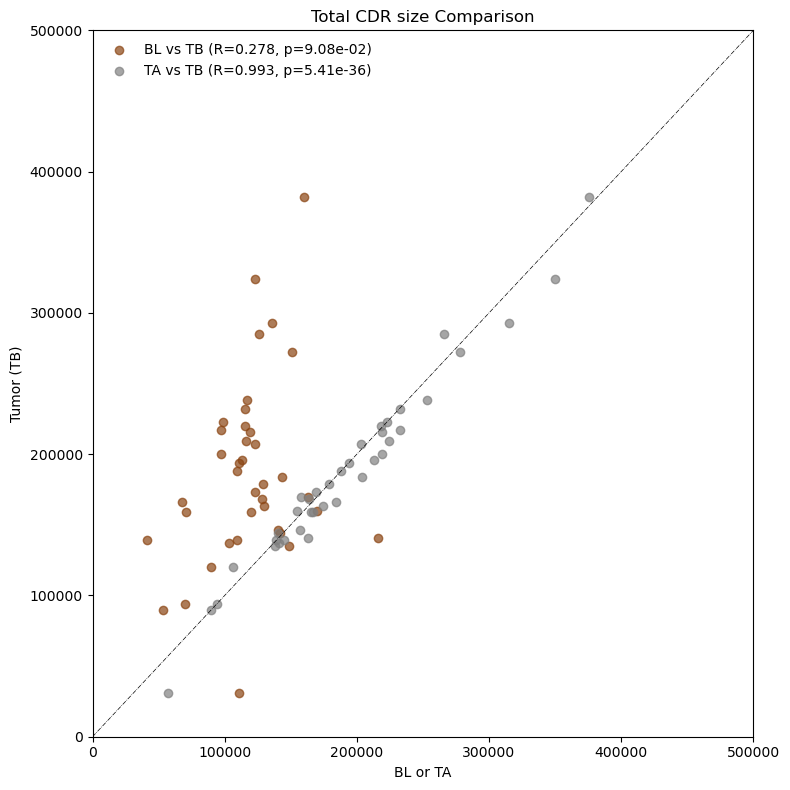

/Users/danilodubocanin/miniconda3/envs/ARM/lib/python3.10/site-packages/seaborn/categorical.py:3544: UserWarning: 17.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


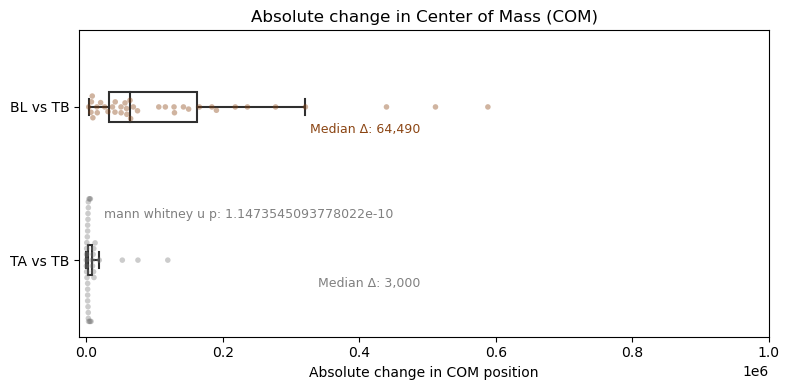

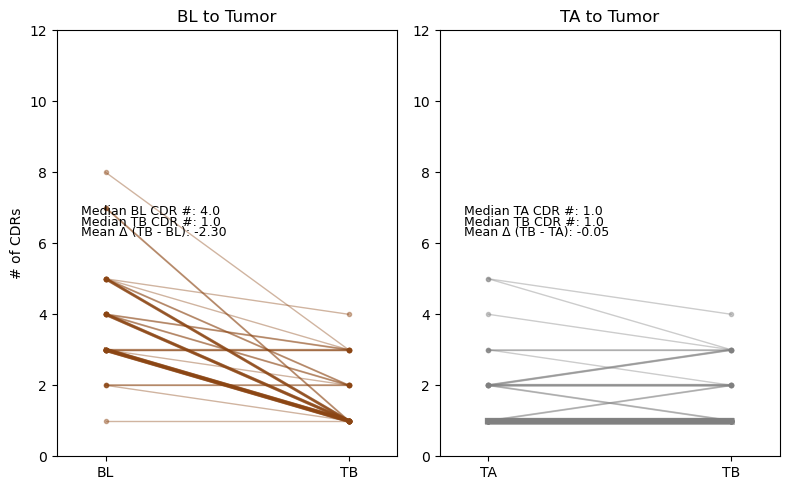

In [24]:
def analyze_triplet_overlaid(
    bl_file: str, ta_file: str, tb_file: str, alpha_sat_file: str, output_prefix=False
):

    print("==================================================")
    print(" Analyzing Triplet: BL vs TB  &  TA vs TB")
    print("==================================================\n")

    # =============================================================================
    # 1. CALCULATE RAW DATA
    # =============================================================================
    # Center of mass
    bl_com = center_of_mass_per_chrom(bl_file, alpha_sat_file, contained_only=True)
    ta_com = center_of_mass_per_chrom(ta_file, alpha_sat_file, contained_only=True)
    tb_com = center_of_mass_per_chrom(tb_file, alpha_sat_file, contained_only=True)
    
    # CDR Size
    bl_size = cdr_size(bl_file, alpha_sat_file, contained_only=True)
    ta_size = cdr_size(ta_file, alpha_sat_file, contained_only=True)
    tb_size = cdr_size(tb_file, alpha_sat_file, contained_only=True)
    
    # CDR Counts
    res_bl_tb = count_entries_per_region(bl_file, tb_file, alpha_sat_file, contained_only=False)
    res_ta_tb = count_entries_per_region(ta_file, tb_file, alpha_sat_file, contained_only=False)


    # =============================================================================
    # 1.5 FILTER EXTREME OUTLIERS (> 1MB COM DELTA)
    # =============================================================================
    excluded_bl_tb = set()
    common_bl_tb = set(bl_com.keys()) & set(tb_com.keys())
    for k in common_bl_tb:
        if bl_com[k] is not None and tb_com[k] is not None:
            if abs(bl_com[k] - tb_com[k]) > 1_000_000:
                print(f"[FILTER] Excluded {k} from BL vs TB (COM delta > 1MB)")
                excluded_bl_tb.add(k)

    excluded_ta_tb = set()
    common_ta_tb = set(ta_com.keys()) & set(tb_com.keys())
    for k in common_ta_tb:
        if ta_com[k] is not None and tb_com[k] is not None:
            if abs(ta_com[k] - tb_com[k]) > 1_000_000:
                print(f"[FILTER] Excluded {k} from TA vs TB (COM delta > 1MB)")
                excluded_ta_tb.add(k)


    # =============================================================================
    # 2. OVERLAID SCATTER PLOT (CDR SIZE)
    # =============================================================================
    # Gather BL vs TB points
    size_bl, size_tb_from_bl = [], []
    for k in (set(bl_size.keys()) & set(tb_size.keys())) - excluded_bl_tb:
        if bl_size[k] and tb_size[k]:
            size_bl.append(bl_size[k])
            size_tb_from_bl.append(tb_size[k])

    # Gather TA vs TB points
    size_ta, size_tb_from_ta = [], []
    for k in (set(ta_size.keys()) & set(tb_size.keys())) - excluded_ta_tb:
        if ta_size[k] and tb_size[k]:
            size_ta.append(ta_size[k])
            size_tb_from_ta.append(tb_size[k])

    # Stats
    r_bl, p_bl = linregress(size_bl, size_tb_from_bl).rvalue, linregress(size_bl, size_tb_from_bl).pvalue
    r_ta, p_ta = linregress(size_ta, size_tb_from_ta).rvalue, linregress(size_ta, size_tb_from_ta).pvalue

    # Plot
    plt.figure(figsize=(8, 8))
    plt.title('Total CDR size Comparison')
    plt.xlabel('BL or TA')
    plt.ylabel('Tumor (TB)')

    plt.scatter(
        size_bl, size_tb_from_bl, color='saddlebrown', alpha=0.7, 
        label=f'BL vs TB (R={r_bl:.3f}, p={p_bl:.2e})'
    )
    plt.scatter(
        size_ta, size_tb_from_ta, color='gray', alpha=0.7, 
        label=f'TA vs TB (R={r_ta:.3f}, p={p_ta:.2e})'
    )

    plt.plot([0, 500_000], [0, 500_000], ls='dashdot', c='black', lw=0.5, zorder=1)
    plt.xlim(0, 500_000)
    plt.ylim(0, 500_000)
    plt.legend(loc='upper left', frameon=False)
    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_CDR_size.pdf',dpi=350)
        plt.show()
    else:
        plt.show()

    # =============================================================================
    # 3. SEPARATE COM PLOTS (Grouped horizontally for easy reading)
    # =============================================================================
    delta_bl_tb = [abs(bl_com[k] - tb_com[k]) for k in common_bl_tb - excluded_bl_tb if bl_com[k] is not None and tb_com[k] is not None]
    delta_ta_tb = [abs(ta_com[k] - tb_com[k]) for k in common_ta_tb - excluded_ta_tb if ta_com[k] is not None and tb_com[k] is not None]

    plt.figure(figsize=(8, 4))
    plt.title('Absolute change in Center of Mass (COM)')
    plt.xlabel('Absolute change in COM position')

    sns.boxplot(
        data=[delta_bl_tb, delta_ta_tb], orient='h', width=0.2, fliersize=0, 
        palette=['saddlebrown', 'gray'], boxprops={'facecolor': 'none'}
    )
    sns.swarmplot(
        data=[delta_bl_tb, delta_ta_tb], orient='h', alpha=0.4, size=4, 
        palette=['saddlebrown', 'gray']
    )

    plt.yticks([0, 1], ['BL vs TB', 'TA vs TB'])
    plt.xlim(-10_000, 1_000_000)
    
    # Text Medians
    plt.text(490_000, 0.15, f'Median Δ: {int(np.nanmedian(delta_bl_tb)):,}', va='center', ha='right', fontsize=9, color='saddlebrown')
    plt.text(490_000, 1.15, f'Median Δ: {int(np.nanmedian(delta_ta_tb)):,}', va='center', ha='right', fontsize=9, color='gray')
    
    u,p = mannwhitneyu(delta_bl_tb,delta_ta_tb)
    
    plt.text(450_000, 0.7, f'mann whitney u p: {p}', va='center', ha='right', fontsize=9, color='gray')
    
    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_COM.pdf',dpi=350)
        plt.show()
    else:
        plt.show()


    fig, axes = plt.subplots(1, 2, figsize=(8, 5))
    
    # BL vs TB
    keys_bl_tb = plot_paired_counts(axes[0], res_bl_tb, 'BL', 'TB', 'saddlebrown')
    axes[0].set_ylabel("# of CDRs")
    axes[0].set_title("BL to Tumor")

    # TA vs TB
    keys_ta_tb = plot_paired_counts(axes[1], res_ta_tb, 'TA', 'TB', 'gray')
    axes[1].set_title("TA to Tumor")
    axes[1].set_ylim(0,12)
    axes[0].set_ylim(0,12)

    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_CDR_count.pdf',dpi=350)
        plt.show()
    else:
        plt.show()
    

    
colo_alpha_sat_file= 'colo/DSA_COLO829BL_v3.0.0_1_2.trimmed_CHM13-centromere.stats.DSA.start2end.ALR_Alpha.100kb.10kb_merge.bed'

colo_bl_file = 'colo/bl/COLO829BL_DSA.combined.zhtr_minus1_25.bed'

colo_ta_file = 'colo/t/COLO829TA_DSA.combined.zhtr_minus1_25.bed'
colo_tb_file = 'colo/t/COLO829TB_DSA.combined.zhtr_minus1_25.bed'

analyze_triplet_overlaid(
    bl_file=colo_bl_file,
    ta_file=colo_ta_file,
    tb_file=colo_tb_file,
    alpha_sat_file=colo_alpha_sat_file, output_prefix = None
)


 Processing 2 Pairs for Consolidated Plotting

--- Pre-pass: collecting global CDR sizes for percentile filtering ---
    Global size thresholds → low: 21,600 bp  |  high: 174,800 bp

--- Processing: ST001 Lung vs ST001 Liver ---
--- Processing: ST002 Lung vs ST002 Colon ---


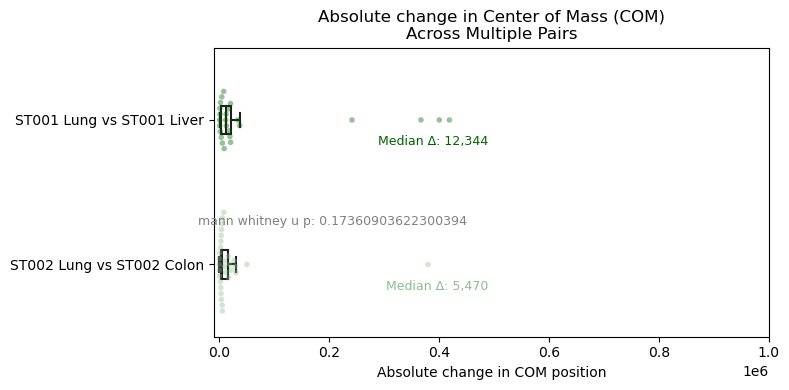

ST001 Lung 132000.0
ST001 Liver 130000.0
ST002 Lung 117000.0
ST002 Colon 128500.0


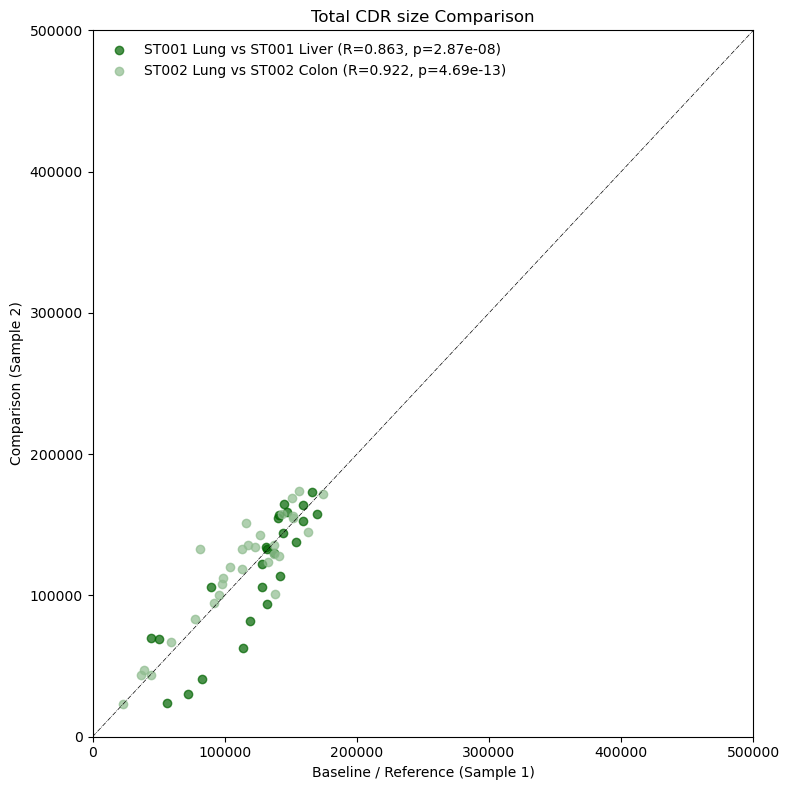

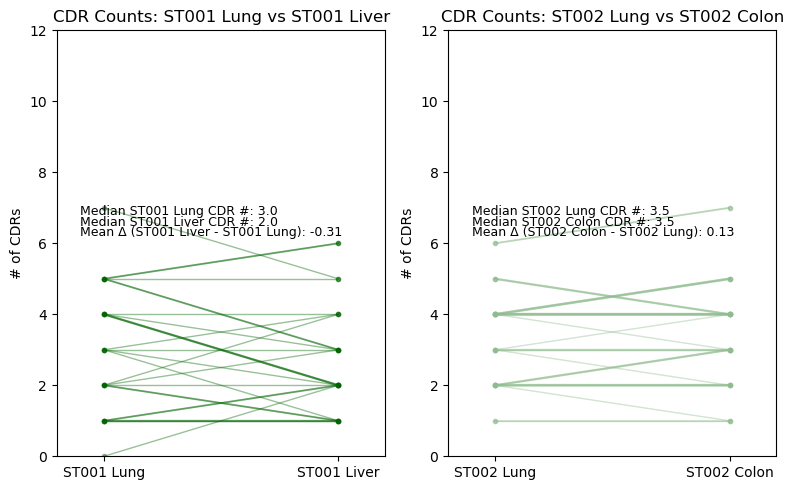

In [25]:
 
 # Define your files
st001_alpha_sat_file = 'st001/ST001.centromeres.merge_10kb.bed'
st001_lung_file = 'st001/ST001_lung.centromere.modkit.clean.cdr_minus1.75.bed'
st001_liver_file = 'st001/ST001_liver.centromere.modkit.clean.cdr_minus1.75.bed'

 # Define your files
st002_alpha_sat_file = 'st002/ST002.centromeres.merge_10kb.bed'
st002_lung_file = 'st002/ST002_lung.centromere.modkit.clean.cdr_minus1_75.bed'
st002_colon_file = 'st002/ST002_colon.centromere.modkit.clean.cdr_minus1_75.bed'


def analyze_multiple_cdr_pairs(pairs_config: list, output_prefix = None, filter_size_outliers: bool = True):
    
    com_plot_data = []
    com_plot_labels = []
    com_plot_colors = []
    
    scatter_plot_data = []
    counts_plot_data = []
    print("==================================================")
    print(f" Processing {len(pairs_config)} Pairs for Consolidated Plotting")
    print("==================================================\n")


    if filter_size_outliers:
        print("--- Pre-pass: collecting global CDR sizes for percentile filtering ---")
    else:
        print("--- Pre-pass: size-outlier filter DISABLED (filter_size_outliers=False) ---")

    raw_cache = []
    all_sizes = []   

    for pair in pairs_config:
        s1_file  = pair['sample1_file']
        s2_file  = pair['sample2_file']
        alpha_file = pair['alpha_sat_file']

        s1_com  = center_of_mass_per_chrom(s1_file,  alpha_file, contained_only=True)
        s2_com  = center_of_mass_per_chrom(s2_file,  alpha_file, contained_only=True)
        s1_size = cdr_size(s1_file, alpha_file, contained_only=True)
        s2_size = cdr_size(s2_file, alpha_file, contained_only=True)
        res_counts = count_entries_per_region(s1_file, s2_file, alpha_file, contained_only=False)

        raw_cache.append((s1_com, s2_com, s1_size, s2_size, res_counts))

        # Accumulate every non-None size value into the global pool
        for v in s1_size.values():
            if v:
                all_sizes.append(v)
        for v in s2_size.values():
            if v:
                all_sizes.append(v)

    # Compute global size thresholds once (only used if filter_size_outliers=True)
    if filter_size_outliers:
        size_low  = float(np.percentile(all_sizes,  10)) if all_sizes else 0
        size_high = float(np.percentile(all_sizes, 90)) if all_sizes else float('inf')
        print(f"    Global size thresholds → low: {size_low:,.0f} bp  |  high: {size_high:,.0f} bp\n")
    else:
        size_low, size_high = float('-inf'), float('inf')
        print("    (size thresholds bypassed)\n")

    # =============================================================================
    # 1. LOOP THROUGH PAIRS TO CALCULATE & FILTER DATA
    # =============================================================================
    for i, pair in enumerate(pairs_config):
        s1_name = pair['sample1_name']
        s2_name = pair['sample2_name']
        color   = pair.get('plot_color', 'gray')
        pair_label = f"{s1_name} vs {s2_name}"
        print(f"--- Processing: {pair_label} ---")

        s1_com, s2_com, s1_size, s2_size, res_counts = raw_cache[i]


        size_outlier_contigs = set()
        if filter_size_outliers:
            for k in set(s1_size.keys()) | set(s2_size.keys()):
                v1 = s1_size.get(k)
                v2 = s2_size.get(k)
                if (v1 and not (size_low <= v1 <= size_high)) or \
                   (v2 and not (size_low <= v2 <= size_high)):
                    size_outlier_contigs.add(k)

        com_outlier_contigs = set()
        common_com_keys = set(s1_com.keys()) & set(s2_com.keys())
        for k in common_com_keys:
            if s1_com[k] is not None and s2_com[k] is not None:
                if abs(s1_com[k] - s2_com[k]) > 1_000_000:
                    com_outlier_contigs.add(k)

        excluded_contigs = size_outlier_contigs | com_outlier_contigs

        delta_list = []
        for k in common_com_keys - excluded_contigs:
            if s1_com[k] is not None and s2_com[k] is not None:
                delta_list.append(abs(s1_com[k] - s2_com[k]))

        com_plot_data.append(delta_list)
        com_plot_labels.append(pair_label)
        com_plot_colors.append(color)

        cdr_sizes_s1, cdr_sizes_s2 = [], []
        common_size_keys = set(s1_size.keys()) & set(s2_size.keys())
        for k in common_size_keys - excluded_contigs:
            if s1_size[k] and s2_size[k]:
                cdr_sizes_s1.append(s1_size[k])
                cdr_sizes_s2.append(s2_size[k])

        if cdr_sizes_s1 and cdr_sizes_s2:
            lr = linregress(cdr_sizes_s1, cdr_sizes_s2)
            scatter_plot_data.append({
                'x': cdr_sizes_s1, 'y': cdr_sizes_s2, 'label': pair_label,
                'color': color, 'r': lr.rvalue, 'p': lr.pvalue,
                's1_name': s1_name, 's2_name': s2_name
            })

        filtered_counts = (
            {k: v for k, v in res_counts.items() if k not in excluded_contigs}
            if isinstance(res_counts, dict) else res_counts
        )
        counts_plot_data.append({
            'res': filtered_counts, 's1_name': s1_name, 's2_name': s2_name,
            'color': color, 'label': pair_label
        })
    

    # =============================================================================
    # 2.  COM PLOT
    # =============================================================================
    fig_height = max(4, 1.5 * len(pairs_config))
    plt.figure(figsize=(8, fig_height))
    plt.title('Absolute change in Center of Mass (COM)\nAcross Multiple Pairs')
    plt.xlabel('Absolute change in COM position')

    sns.boxplot(
        data=com_plot_data, orient='h', width=0.2, fliersize=0, 
        palette=com_plot_colors, boxprops={'facecolor': 'none'}
    )
    sns.swarmplot(
        data=com_plot_data, orient='h', alpha=0.4, size=4, 
        palette=com_plot_colors
    )

    plt.yticks(range(len(com_plot_labels)), com_plot_labels)
    plt.xlim(-10_000, 1_000_000)
    
    # Text Medians
    for idx, deltas in enumerate(com_plot_data):
        med_val = int(np.nanmedian(deltas)) if deltas else 0
        plt.text(490_000, idx + 0.15, f'Median Δ: {med_val:,}', va='center', ha='right', fontsize=9, color=com_plot_colors[idx])
    
    u,p = mannwhitneyu(com_plot_data[0],com_plot_data[1])
    
    plt.text(450_000, 0.7, f'mann whitney u p: {p}', va='center', ha='right', fontsize=9, color='gray')    
    
    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_CDR_COM.pdf',dpi=350)
        plt.show()
    else:
        plt.show()
    

    # =============================================================================
    # 3. SIZE SCATTER PLOT
    # =============================================================================
    plt.figure(figsize=(8, 8))
    plt.title('Total CDR size Comparison')
    plt.xlabel('Baseline / Reference (Sample 1)')
    plt.ylabel('Comparison (Sample 2)')

    for sp_data in scatter_plot_data:
        plt.scatter(
            sp_data['x'], sp_data['y'], color=sp_data['color'], alpha=0.7, 
            label=f"{sp_data['label']} (R={sp_data['r']:.3f}, p={sp_data['p']:.2e})"
        )
        print(sp_data['s1_name'],np.median(sp_data['x']))
        print(sp_data['s2_name'],np.median(sp_data['y']))
              
    plt.plot([0, 500_000], [0, 500_000], ls='dashdot', c='black', lw=0.5, zorder=1)
    plt.xlim(0, 500_000)
    plt.ylim(0, 500_000)
    plt.legend(loc='upper left', frameon=False)
    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_CDR_size.pdf',dpi=350)
        plt.show()
    else:
        plt.show()
    

    # =============================================================================
    # 4.  CDR COUNTS PLOT (Subplots side-by-side)
    # =============================================================================
    n_pairs = len(counts_plot_data)
    fig, axes = plt.subplots(1, n_pairs, figsize=(4 * n_pairs, 5))
    
    # Ensure axes is iterable even if there is only 1 pair
    if n_pairs == 1:
        axes = [axes]
        
    for ax, cp_data in zip(axes, counts_plot_data):
        plot_paired_counts(ax, cp_data['res'], cp_data['s1_name'], cp_data['s2_name'], cp_data['color'])
        ax.set_title(f"CDR Counts: {cp_data['label']}")
        ax.set_ylabel("# of CDRs")
        ax.set_ylim(0,12)
    plt.tight_layout()
    if output_prefix:
        plt.savefig(output_prefix+'_change_in_CDR_count.pdf',dpi=350)
        plt.show()
    else:
        plt.show()
        
        
# Create the configuration list
my_pairs = [
    {
        'sample1_name': 'ST001 Lung',
        'sample1_file': st001_lung_file,
        'sample2_name': 'ST001 Liver',
        'sample2_file': st001_liver_file,
        'alpha_sat_file': st001_alpha_sat_file,
        'plot_color': 'darkgreen'
    },
    {
        'sample1_name': 'ST002 Lung',
        'sample1_file': st002_lung_file,
        'sample2_name': 'ST002 Colon',
        'sample2_file': st002_colon_file,
        'alpha_sat_file': st002_alpha_sat_file,
        'plot_color': 'darkseagreen'
    }
]

# Run the consolidated function
# analyze_multiple_cdr_pairs(my_pairs, output_prefix='ST001and2_minus1.75')
analyze_multiple_cdr_pairs(my_pairs,filter_size_outliers=True) #output_prefix='ST001and2_minus1.75_notop_bottom_decile')


 Processing 2 Pairs for Consolidated Plotting

--- Pre-pass: size-outlier filter DISABLED (filter_size_outliers=False) ---
    (size thresholds bypassed)

--- Processing: D1 F. (GM25456) vs D1 L. (GM25455) ---
--- Processing: D2 F. (GM28572) vs D2 L. (GM28570) ---


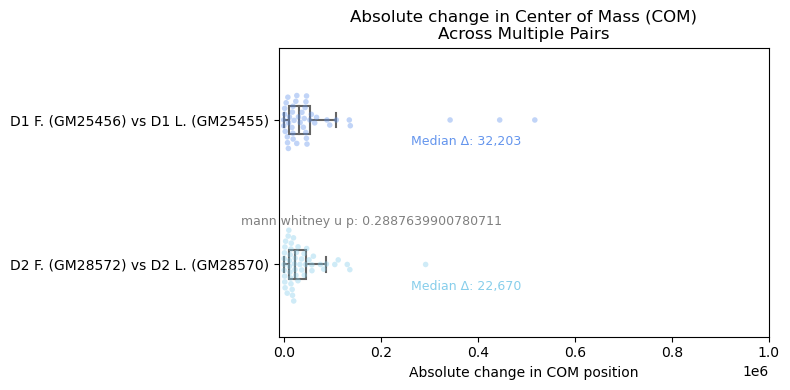

D1 F. (GM25456) 146000.0
D1 L. (GM25455) 107000.0
D2 F. (GM28572) 140500.0
D2 L. (GM28570) 118500.0


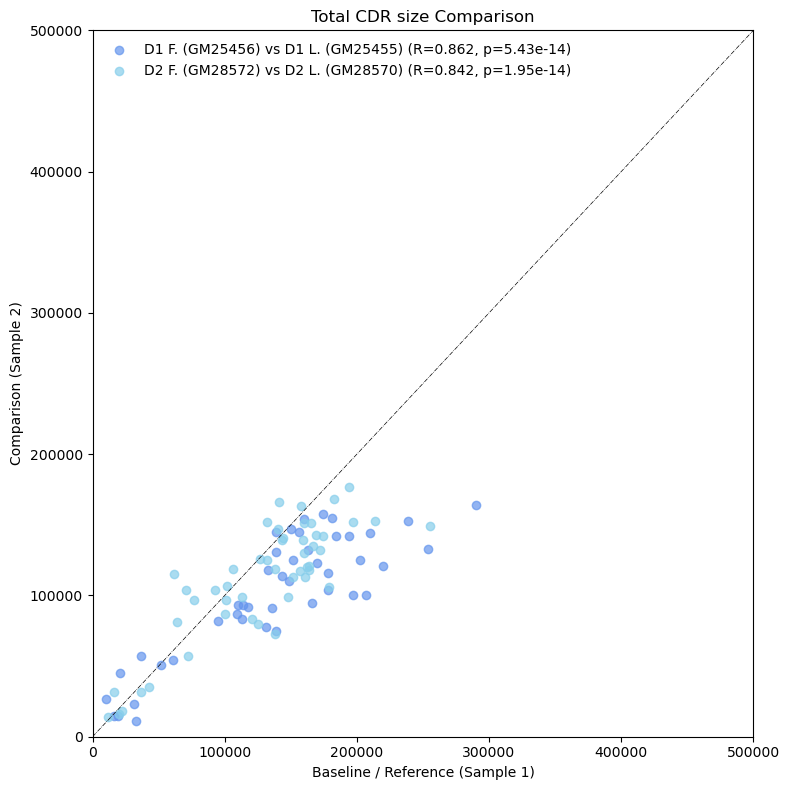

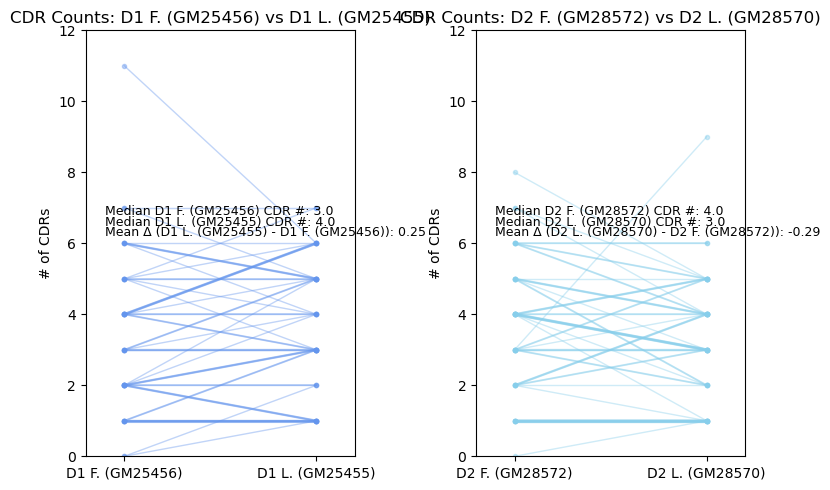

In [17]:
# fibroblast vs lcl 


# donor1
donor1_alpha_sat = 'fibroblast_and_lcl/donor1/GM25456_GM25455_DSA_1_2_CHM13-centromere.stats.DSA.start2end.ALR_Alpha.100kb.merge_10kb.bed'
donor1_lcl   = 'fibroblast_and_lcl/donor1/GM25455_LCL_Fiber-seq_merged.centromere.aligned_bam_to_cpg_scores.combined.cdr_minus1.25.bed'
donor1_fibro = 'fibroblast_and_lcl/donor1/GM25456_Fibroblast_Fiber-seq_merged.centromere.aligned_bam_to_cpg_scores.combined.cdr_minus1.25.bed'

# donor2
donor2_alpha_sat = 'fibroblast_and_lcl/donor2/GM28572_GM28570_DSA_1_2_CHM13-centromere.stats.DSA.start2end.ALR_Alpha.100kb.merge_10kb.bed'
donor2_lcl   = 'fibroblast_and_lcl/donor2/GM28570_LCL_Fiber-seq_merged.centromere.aligned_bam_to_cpg_scores.combined.minus_1.25.bed'
donor2_fibro = 'fibroblast_and_lcl/donor2/GM28572_Fibroblast_Fiber-seq_merged.centromere.aligned_bam_to_cpg_scores.combined.minus_1.25.bed'

# Create the configuration list
my_pairs = [
    {
        'sample1_name': 'D1 F. (GM25456)',
        'sample1_file': donor1_fibro,
        'sample2_name': 'D1 L. (GM25455)',
        'sample2_file': donor1_lcl,
        'alpha_sat_file': donor1_alpha_sat,
        'plot_color': 'cornflowerblue'
    },
    {
        'sample1_name': 'D2 F. (GM28572)',
        'sample1_file': donor2_fibro,
        'sample2_name': 'D2 L. (GM28570)',
        'sample2_file': donor2_lcl,
        'alpha_sat_file': donor2_alpha_sat,
        'plot_color': 'skyblue'
    }
]

# Run the consolidated function
# analyze_multiple_cdr_pairs(my_pairs,output_prefix='Fibroblast_vs_LCL_')
analyze_multiple_cdr_pairs(my_pairs,output_prefix=None,filter_size_outliers=False)

In [26]:
import pyBigWig
import pandas as pd
import random

def extract_bw_values(bed_file, bw_file, sample_name):
    """
    Extracts all non-NaN values from a BigWig file within the regions defined in a BED file.
    """
    values = []
    try:
        bw = pyBigWig.open(bw_file)
    except Exception as e:
        print(f"[ERROR] Could not open {bw_file}: {e}")
        return pd.DataFrame()

    with open(bed_file, 'r') as f:
        for line in f:
            if not line.strip(): 
                continue
                
            parts = line.strip().split()
            chrom = parts[0]
            start = int(parts[1])
            end = int(parts[2])
            
            try:
                # Retrieve the raw values for each base in the region
                vals = bw.values(chrom, start, end)
                if vals:
                    # Filter out NaNs
                    clean_vals = [v for v in vals if not np.isnan(v)]
                    values.extend(clean_vals)
            except RuntimeError:
                # This catches errors if the chromosome isn't in the bigwig 
                # (e.g., 'chr1' vs '1' formatting differences)
                pass
                
    bw.close()
    
    # Return as a DataFrame to make Seaborn plotting easy
    return pd.DataFrame({'Sample': sample_name, 'Value': values})

# =============================================================================
# 1. DEFINE FILES & CONFIGURATION
# =============================================================================
# BED files
smhtbla2_fibroblast_cdr   = 'smhtbl/SMHTLBLA2_ONT_merged_resetmapq.centromere_slop.cdr_minus175.bed'

# Configuration List: (Sample Name, BED File, BigWig File, Color)
samples_config = [
    ("Fibroblast", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBLA2_ONT_merged_resetmapq.centromere_slop.bw', "gray"),
    ("iPSC 1", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBIPSC1_1_resetmapq.combined.bw', "#DDA0DD"),   # Plum (light purple)
    ("iPSC 2", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBIPSC2_merged_resetmapq.combined.bw', "#DA70D6"), # Orchid
    ("iPSC 4_1", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBIPSC4_1_resetmapq.combined.bw', "#BA55D3"), # Medium Orchid
    ("iPSC 52", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBIPSC52_1_resetmapq.combined.bw', "#9932CC"), # Dark Orchid
    ("iPSC 60", smhtbla2_fibroblast_cdr, 'smhtbl/SMHTLBIPSC60_merged_resetmapq.combined.bw', "#4B0082")  # Indigo (dark purple)
]

# =============================================================================
# 2. EXTRACT DATA
# =============================================================================
print("Extracting BigWig values... this might take a moment depending on region size.")
df_list = []
palette = {}

for name, bed, bw, color in samples_config:
    print(f"Processing {name}...")
    df_sample = extract_bw_values(bed, bw, name)
    

        
    df_list.append(df_sample)
    palette[name] = color

df_all = pd.concat(df_list, ignore_index=True)


Extracting BigWig values... this might take a moment depending on region size.
Processing Fibroblast...
Processing iPSC 1...
Processing iPSC 2...
Processing iPSC 4_1...
Processing iPSC 52...
Processing iPSC 60...


=== Median Values ===
Fibroblast: 28.4200
iPSC 1: 83.2000
iPSC 2: 85.6000
iPSC 4_1: 84.6000
iPSC 52: 83.1000
iPSC 60: 85.9000

=== Mann-Whitney U Tests (vs LCL) ===
Fibroblast vs iPSC 1: MWU p-value = 0.0
Fibroblast vs iPSC 2: MWU p-value = 0.0
Fibroblast vs iPSC 4_1: MWU p-value = 0.0
Fibroblast vs iPSC 52: MWU p-value = 0.0
Fibroblast vs iPSC 60: MWU p-value = 0.0



/var/folders/_g/p69fnyf973l44t6hp4m04mdw0000gn/T/ipykernel_2565/1242935725.py:38: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(


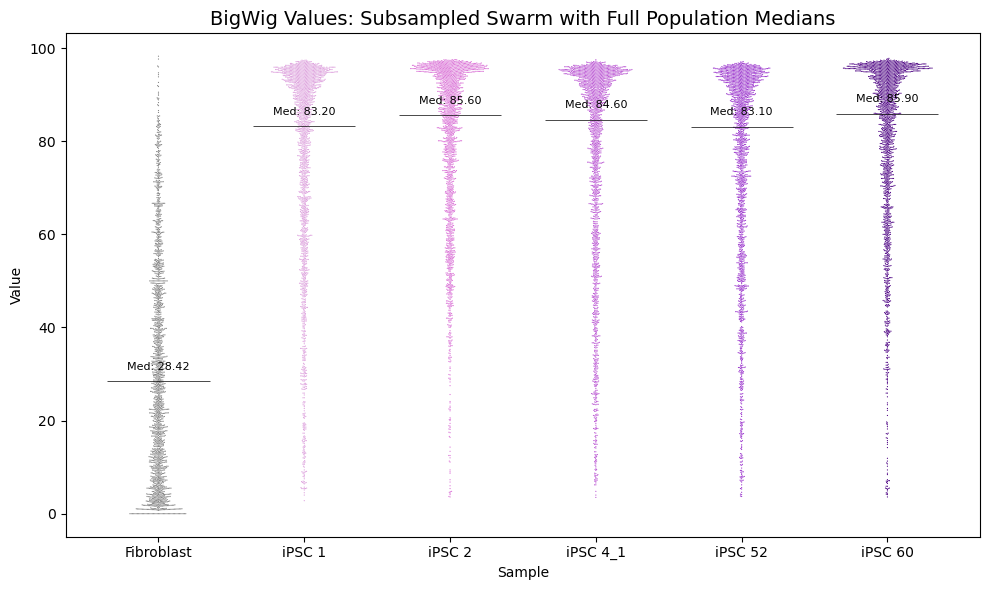

In [27]:
# 1. PRE-CALCULATE STATISTICS 
groups_full = {name: group['Value'].dropna().values for name, group in df_all.groupby('Sample')}

medians_full = {name: np.median(val) for name, val in groups_full.items()}

lcl_name = "Fibroblast"
lcl_data = groups_full[lcl_name]
ipsc_lines = [s for s in medians_full.keys() if 'iPSC' in s]

sample_names = list(df_all['Sample'].unique())
sample_to_x = {sample: i for i, sample in enumerate(sample_names)}


print("=== Median Values ===")
for name, median in medians_full.items():
    print(f"{name}: {median:.4f}")

print("\n=== Mann-Whitney U Tests (vs LCL) ===")
mwu_pvalues = {}
for ipsc in ipsc_lines:
    ipsc_data = groups_full[ipsc]
    stat, p_val = mannwhitneyu(lcl_data, ipsc_data, alternative='two-sided')
    mwu_pvalues[ipsc] = p_val
    print(f"Fibroblast vs {ipsc}: MWU p-value = {p_val}")
print("=====================================\n")

# Subsampling 2000 points (or max available)
df_subsampled = df_all.groupby('Sample', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 2000), random_state=42, replace=False)
).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.title('BigWig Values: Subsampled Swarm with Full Population Medians', fontsize=14)

palette = {sample[0]: sample[3] for sample in samples_config}

# Swarmplot (Subsampled points)
sns.swarmplot(
    data=df_subsampled, 
    x='Sample', 
    y='Value', 
    palette=palette, 
    size=0.85, 
    alpha=1,
    zorder=1
)

# Draw Black Median Lines (Calculated from full dataset)
for i, sample in enumerate(sample_names):
    m_val = medians_full[sample]
    plt.hlines(y=m_val, xmin=i-0.35, xmax=i+0.35, color='black', linewidth=0.5, zorder=3)
    
    plt.text(i, m_val + (df_all['Value'].max() * 0.02), f"Med: {m_val:.2f}", 
             ha='center', va='bottom', fontsize=8, zorder=4)
    

plt.tight_layout()
# plt.savefig("Fibroblast_vs_iPSC_Comparison.pdf", format='pdf', bbox_inches='tight')
plt.show()

Calculating COM for Fibroblast...
Calculating COM for iPSC 1...
Calculating COM for iPSC 2...
Calculating COM for iPSC 4_1...
Calculating COM for iPSC 52...
Calculating COM for iPSC 60...


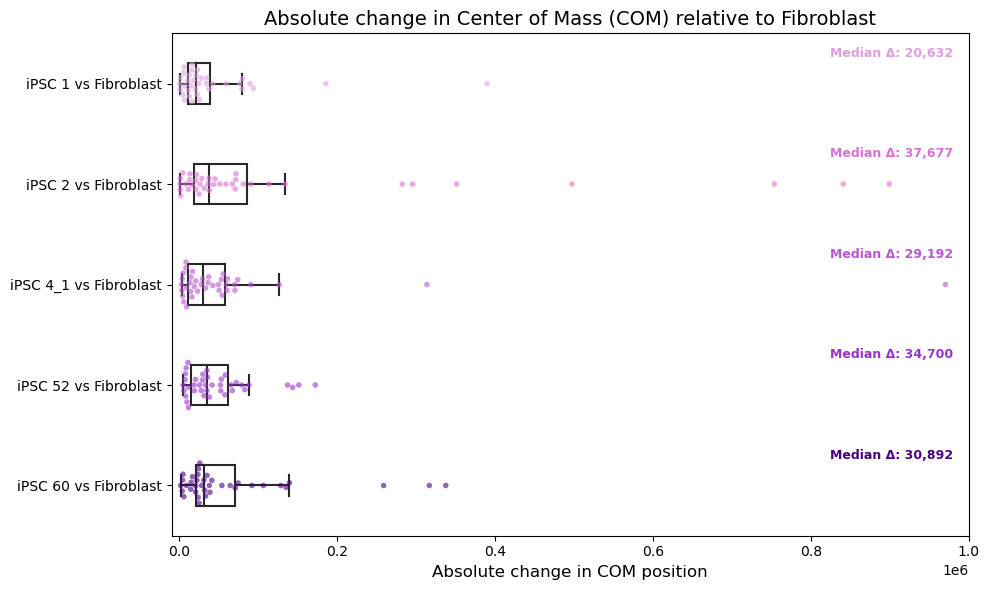

In [29]:
# Configuration List: (Sample Name, BED File, BigWig File, Color)
smhtbla2_alphasat = 'smhtbl/SMHTLBLA2-DSA_1_2_CHM13-centromere.stats.DSA.start2end.ALR_Alpha.100kb.merge_10kb.bed'
smhtbla2_fibroblast_cdr   = 'smhtbl/SMHTLBLA2_ONT_merged_resetmapq.centromere_slop.cdr_minus175.bed'

samples_config_cdr = [
    ("Fibroblast", smhtbla2_alphasat, 'smhtbl/SMHTLBLA2_ONT_merged_resetmapq.centromere_slop.cdr_minus175.bed', "gray"),
    ("iPSC 1", smhtbla2_alphasat, 'smhtbl/SMHTLBIPSC1_1_resetmapq.combined.cdr_minus1.75.bed.bed', "#DDA0DD"),   # Plum 
    ("iPSC 2", smhtbla2_alphasat, 'smhtbl/SMHTLBIPSC2_merged_resetmapq.combined.cdr_minus1.75.bed.bed', "#DA70D6"), # Orchid
    ("iPSC 4_1", smhtbla2_alphasat, 'smhtbl/SMHTLBIPSC4_1_resetmapq.combined.cdr_minus1.75.bed.bed', "#BA55D3"), # Medium Orchid
    ("iPSC 52", smhtbla2_alphasat, 'smhtbl/SMHTLBIPSC52_1_resetmapq.combined.cdr_minus1.75.bed.bed', "#9932CC"), # Dark Orchid
    ("iPSC 60", smhtbla2_alphasat, 'smhtbl/SMHTLBIPSC60_merged_resetmapq.combined.cdr_minus1.75.bed.bed', "#4B0082")  # Indigo 
]

com_results = {}
for name, alpha_sat, bed, color in samples_config_cdr:
    print(f"Calculating COM for {name}...")
    com_results[name] = center_of_mass_per_chrom(bed, alpha_sat, contained_only=True)

lcl_com = com_results["Fibroblast"]
ipsc_samples = [s for s in samples_config_cdr if s[0] != "Fibroblast"]

deltas = []
labels = []
colors = []
mwu_pvalues = [] # Store p-values for plotting

for name, _, _, color in ipsc_samples:
    ipsc_com = com_results[name]
    
    # Find chromosomes present in both LCL and the current iPSC line
    common_chroms = set(lcl_com.keys()).intersection(set(ipsc_com.keys()))
    
    delta_list = []
    raw_lcl_list = []
    raw_ipsc_list = []
    
    for chrom in common_chroms:
        try:
            val_lcl = float(lcl_com[chrom])
            val_ipsc = float(ipsc_com[chrom])
            
            if not np.isnan(val_lcl) and not np.isnan(val_ipsc):
                if abs(val_ipsc - val_lcl) > 1_000_000:
                    continue
                
                delta_list.append(abs(val_ipsc - val_lcl))
                raw_lcl_list.append(val_lcl)
                raw_ipsc_list.append(val_ipsc)
                
        except (ValueError, TypeError):
            continue
            
    deltas.append(delta_list)
    labels.append(f'{name} vs Fibroblast')
    colors.append(color)


plt.figure(figsize=(10, 6))
plt.title('Absolute change in Center of Mass (COM) relative to Fibroblast', fontsize=14)
plt.xlabel('Absolute change in COM position', fontsize=12)

sns.boxplot(
    data=deltas, 
    orient='h', 
    width=0.4, 
    fliersize=0, 
    palette=colors, 
    boxprops={'facecolor': 'none'}
)

sns.swarmplot(
    data=deltas, 
    orient='h', 
    alpha=0.6, 
    size=4, 
    palette=colors
)

plt.yticks(ticks=range(len(labels)), labels=labels)
plt.xlim(-10_000, 1_000_000)


for i, (delta_array, color) in enumerate(zip(deltas, colors)):
    if not delta_array:
        continue
        
    median_val = np.nanmedian(delta_array)
    
    annotation_text = f'Median Δ: {int(median_val):,}'
    
    plt.text(
        980_000, 
        i - 0.3,  # Offset slightly above the swarm
        annotation_text, 
        va='center', 
        ha='right', 
        fontsize=9, 
        color=color,
        fontweight='bold'
    )

plt.tight_layout()

# Save/Show
output_prefix=None

# output_prefix = "CDR_samples_smhtbla2_ipsc_vs_fibro" # Replace with your actual variable if needed
if output_prefix:
    plt.savefig(f'{output_prefix}_change_in_COM.pdf', dpi=350)
    plt.show()
else:
    plt.show()